In [1]:
# ============================================================
# 단계 0 — 환경 설정 · 데이터 로드 · 출처 기록
# ============================================================
!pip install -q koreanize-matplotlib

import os, platform
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy, statsmodels
import koreanize_matplotlib      # 한글 폰트 자동 적용
import kagglehub

# --- 재현성 고정 ---
SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 120)

# --- 데이터 출처 기록 (재현성 요건) ---
DATA_SOURCE   = "https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing"
DOWNLOAD_DATE = date.today().isoformat()

path = kagglehub.dataset_download("yufengsui/mobile-games-ab-testing")
csv_name = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df_raw = pd.read_csv(os.path.join(path, csv_name))
df = df_raw.copy()

# --- 구조만 확인 (지표 값·그룹 간 차이는 아직 보지 않음) ---
print("=" * 60)
print("데이터 출처   :", DATA_SOURCE)
print("내려받은 날짜 :", DOWNLOAD_DATE)
print("파일명        :", csv_name)
print("=" * 60)
print(f"원본 크기     : {len(df_raw):,}행 × {df_raw.shape[1]}열\n")

print("[dtypes]");  print(df.dtypes, "\n")
print("[결측치]");  print(df.isna().sum(), "\n")
print("[head]");    display(df.head())

print(f"\n환경: Python {platform.python_version()} | pandas {pd.__version__} | "
      f"scipy {scipy.__version__} | statsmodels {statsmodels.__version__} | seed={SEED}")

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False   # koreanize 이후 재확인

Using Colab cache for faster access to the 'mobile-games-ab-testing' dataset.
데이터 출처   : https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing
내려받은 날짜 : 2026-07-31
파일명        : cookie_cats.csv
원본 크기     : 90,189행 × 5열

[dtypes]
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object 

[결측치]
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64 

[head]


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True



환경: Python 3.12.13 | pandas 2.2.2 | scipy 1.16.3 | statsmodels 0.14.6 | seed=42


In [2]:
# ============================================================
# 단계 1 — 데이터 위생 점검 (배정 무결성만 확인)
#   ※ 이 단계에서는 그룹별 지표 평균/차이를 보지 않습니다.
#      가설을 잠그기(단계 2) 전에 결과를 엿보면 p-해킹의 입구이므로,
#      여기서는 "배정과 기록이 신뢰할 만한가"만 판단합니다.
# ============================================================
from scipy import stats

CLEAN_LOG = []          # 정제 이력 기록용
n_before = len(df)

# ── 1-1. 중복 확인 ────────────────────────────────────────
dup_rows = df.duplicated().sum()
dup_ids  = df['userid'].duplicated().sum()
print("[1-1] 중복")
print(f"  완전 중복 행      : {dup_rows:,}")
print(f"  중복 userid       : {dup_ids:,}  (고유 {df['userid'].nunique():,} / 전체 {len(df):,})")

# ── 1-2. 배정 일관성 ──────────────────────────────────────
# cookie_cats에는 처치 라벨 컬럼이 version 하나뿐이므로
# "group vs landing_page 불일치" 같은 교차 모순은 구조적으로 발생 불가.
# 대신 (a) 라벨 값이 깨끗한지, (b) 같은 유저가 두 그룹에 동시 배정됐는지 확인.
print("\n[1-2] 배정 일관성")
print(f"  version 고유값    : {df['version'].unique().tolist()}")
print(f"  공백/대소문자 이상: {(df['version'] != df['version'].str.strip().str.lower()).sum()}건")
both = df.groupby('userid')['version'].nunique()
print(f"  두 그룹에 동시 배정된 userid : {(both > 1).sum():,}명")

# ── 1-3. SRM (Sample Ratio Mismatch) ─────────────────────
print("\n[1-3] SRM 점검  (의도 배정비 50:50)")
counts = df['version'].value_counts().sort_index()
n_a, n_b = counts['gate_30'], counts['gate_40']
exp = (n_a + n_b) / 2
chi2, p_srm = stats.chisquare([n_a, n_b], [exp, exp])
print(f"  gate_30 = {n_a:,}  ({n_a/(n_a+n_b)*100:.2f}%)")
print(f"  gate_40 = {n_b:,}  ({n_b/(n_a+n_b)*100:.2f}%)")
print(f"  기대값  = {exp:,.1f} 씩,  차이 = {abs(n_a-n_b):,}명")
print(f"  χ²(1) = {chi2:.3f},  p = {p_srm:.4f}")
print(f"  → {'⚠️ 배정 비율이 의도와 다름 (p<0.05). 배정 로직 의심 신호' if p_srm < 0.05 else '✅ 정상 (p가 충분히 큼)'}")
print("  ※ 여기서는 p가 커야 정상입니다 — 일반 검정과 해석 방향이 반대.")

# ── 1-4. 기록값 타당성 (그룹 구분 없이 전체 분포만) ───────
print("\n[1-4] sum_gamerounds 기록값 타당성 (version 미분리)")
print(df['sum_gamerounds'].describe([.5, .9, .99, .999]).round(2).to_string())
zero_rounds = (df['sum_gamerounds'] == 0).sum()
print(f"\n  0라운드 유저 : {zero_rounds:,}명 ({zero_rounds/len(df)*100:.2f}%) — 설치 후 한 판도 안 함")
print(f"  상위 5개 값  : {sorted(df['sum_gamerounds'].values)[-5:]}")

# ── 1-5. 정제 판단 ────────────────────────────────────────
print("\n[1-5] 정제 판단")

# (a) sum_gamerounds = 49,854 → 데이터 오류로 판단하여 제거
#     근거: 본 데이터는 설치 후 14일 창(window). 49,854라운드는 하루 3,500판 이상으로
#           인간 플레이로 설명 불가 → 봇/로깅 오류. 이는 그룹 간 차이를 본 뒤가 아니라
#           '값 자체가 물리적으로 불가능'하다는 사전 기준에 따른 제거.
mask_impossible = df['sum_gamerounds'] > 40000
n_impossible = mask_impossible.sum()
df = df[~mask_impossible].copy()
CLEAN_LOG.append(f"sum_gamerounds > 40000 제거: {n_impossible}행 "
                 f"(14일 창에서 물리적으로 불가능한 기록 → 로깅 오류로 판단)")

# (b) 0라운드 유저 → 유지 (ITT 원칙)
#     근거: 게임을 시작하지 않은 유저를 빼면 '처치 노출 여부'로 표본을 거르는 것이 되어
#           post-treatment selection 편향이 생김. 의도치료(ITT) 기준으로 전원 유지.
CLEAN_LOG.append(f"0라운드 유저 {zero_rounds:,}명 유지 (ITT 원칙, post-treatment 선택편향 방지)")

n_after = len(df)
print(f"  정제 전 : {n_before:,}행")
print(f"  정제 후 : {n_after:,}행   (제거 {n_before - n_after:,}행, {(n_before-n_after)/n_before*100:.4f}%)")
print("\n  [정제 이력]")
for i, log in enumerate(CLEAN_LOG, 1):
    print(f"   {i}) {log}")

# 5단계(B)에서 이상치 제거 전/후 결론 비교에 쓸 원본 보관
df_with_outlier = df_raw.copy()
print("\n  ※ 5단계 민감도 분석용으로 df_with_outlier(원본) 보관")

[1-1] 중복
  완전 중복 행      : 0
  중복 userid       : 0  (고유 90,189 / 전체 90,189)

[1-2] 배정 일관성
  version 고유값    : ['gate_30', 'gate_40']
  공백/대소문자 이상: 0건
  두 그룹에 동시 배정된 userid : 0명

[1-3] SRM 점검  (의도 배정비 50:50)
  gate_30 = 44,700  (49.56%)
  gate_40 = 45,489  (50.44%)
  기대값  = 45,094.5 씩,  차이 = 789명
  χ²(1) = 6.902,  p = 0.0086
  → ⚠️ 배정 비율이 의도와 다름 (p<0.05). 배정 로직 의심 신호
  ※ 여기서는 p가 커야 정상입니다 — 일반 검정과 해석 방향이 반대.

[1-4] sum_gamerounds 기록값 타당성 (version 미분리)
count    90189.00
mean        51.87
std        195.05
min          0.00
50%         16.00
90%        134.00
99%        493.00
99.9%     1073.62
max      49854.00

  0라운드 유저 : 3,994명 (4.43%) — 설치 후 한 판도 안 함
  상위 5개 값  : [np.int64(2294), np.int64(2438), np.int64(2640), np.int64(2961), np.int64(49854)]

[1-5] 정제 판단
  정제 전 : 90,189행
  정제 후 : 90,188행   (제거 1행, 0.0011%)

  [정제 이력]
   1) sum_gamerounds > 40000 제거: 1행 (14일 창에서 물리적으로 불가능한 기록 → 로깅 오류로 판단)
   2) 0라운드 유저 3,994명 유지 (ITT 원칙, post-treatment 선택편향 방지)

  ※ 5단계 민감도 분석용으로 df_with_outlier(원본) 보관

## 2. 질문과 가설

### 2.1 분석 질문
> **"게임의 진행 관문(gate)을 레벨 30에서 레벨 40으로 미루면, 유저가 더 오래 남는가?"**

제품 가설의 논리: 관문에 더 늦게 부딪히면 초반 이탈 마찰이 줄어들어 잔존율이 올라갈 것이다.

### 2.2 지표 사전 선언
| 구분 | 지표 | 역할 |
|---|---|---|
| **주 지표 (primary)** | `retention_7` | 이 검정 결과 **하나로** 의사결정한다 |
| 보조 (secondary) | `retention_1` | 초기 참여 확인용. 결론의 근거로 쓰지 않음 |
| 보조 (secondary) | `sum_gamerounds` | 참여 강도 참고용. 결론의 근거로 쓰지 않음 |

**주 지표를 `retention_7`로 정한 이유:** 관문 위치 변경의 목적이 *장기 잔존*이므로, 개입의 의도와 지표가 직접 맞물린다. `retention_1`은 개입 시점(레벨 30~40 도달)보다 관측 시점이 이를 수 있어 처치 노출이 불완전하다.

**다중비교 처리 방침(사전 선언):** 지표 3개를 모두 검정하면 검정 3회이므로 α가 부풀려진다. 따라서 주 지표 1개에만 α = 0.05를 배정하고, 보조 지표 2개는 **탐색적(exploratory)** 으로만 보고하며 유의성 판정으로 결론을 바꾸지 않는다. 보조 지표가 유의해도 그것을 근거로 의사결정하지 않는다.

### 2.3 가설
- A군 = `gate_30` (대조군, 현행), B군 = `gate_40` (실험군, 관문 지연)
- p_A, p_B = 각 군의 7일 잔존율

$$H_0: p_A = p_B \qquad H_1: p_A \neq p_B$$

### 2.4 유의수준과 검정 방향
- **α = 0.05**
- **양측 검정.** 제품 가설은 "B가 더 좋다"는 방향을 예상하지만, 관문 지연이 잔존율을 **떨어뜨릴** 가능성도 실질적으로 존재한다(관문은 결제·휴식 유도 장치이기도 하므로). 어느 방향이든 감지해야 하므로 단측을 쓰지 않는다.

### 2.5 사전 의사결정 규칙
결과를 보기 전에 판단 기준을 못 박는다.

| 조건 | 결정 |
|---|---|
| p < 0.05 이고 B가 더 높음, 95% CI 하한 > 0 | gate_40 출시 |
| p < 0.05 이고 B가 더 낮음 | gate_30 유지 (출시 철회) |
| p ≥ 0.05 | 유지 + MDE 확인 후 "효과 없음"과 "검출력 부족"을 구분 |

**추가 규칙:** 결과를 본 뒤 α·검정 방향·주 지표·정제 기준을 변경하지 않는다. 표본을 더 모으지 않는다(peeking 금지). 사후 검정력(post-hoc power)은 계산하지 않는다.

### 2.6 단계 1 결과의 반영
SRM 점검에서 **χ²(1) = 6.90, p = 0.0086** 으로 배정 비율이 의도한 50:50과 유의하게 다름을 확인했다(gate_30 44,700 / gate_40 45,489). 배정 로직에 접근할 수 없어 원인을 규명할 수 없으므로, **분석은 진행하되 결론은 "배정 누락이 결과와 무관하다"는 검증되지 않은 가정에 의존한다**는 점을 6단계 한계에 명시한다. 이 가정이 깨지면 아래 모든 추정치에 편향이 있을 수 있다.

[3-1] 주 지표 retention_7 — 비율 · 2집단
             n  success  failure     rate
version                                  
gate_30  44699     8501    36198  19.018%
gate_40  45489     8279    37210    18.2%

  가장 작은 셀 도수 = 8,279  (기준 ≥ 10)
  → 정규근사 조건 충족 ✅
  → 표본이 매우 커서 z-근사와 카이제곱이 사실상 동일한 결과를 준다.
    (χ² 통계량 = z² 관계) 따라서 어느 쪽을 써도 되지만,
    비율 차이의 신뢰구간을 자연스럽게 얻을 수 있는 '두 비율 z-검정'을 주 검정으로 쓴다.

  [참고] 분할표 기대도수 최소값 = 8,316.5  (기준 ≥ 5) → 충족
  [참고] 카이제곱 독립성 검정: χ²(1) = 9.9692, p = 0.0016

[3-2] 보조 지표 sum_gamerounds — 연속형 · 2집단
             n    mean  median      std   skew    kurt
version                                               
gate_30  44699  51.342    17.0  102.058  5.940  67.563
gate_40  45489  51.299    16.0  103.294  5.967  63.106

  [정규성] Shapiro-Wilk
   ※ n≈45,000에서는 Shapiro가 아주 미세한 이탈에도 반드시 유의해지므로
     각 군 5,000개 무작위 부표본으로 수행하고, 판단은 시각 진단과 왜도를 함께 본다.
   gate_30: W = 0.4518, p = 3.757e-82 → 정규성 위반
   gate_40: W = 0.4683, p = 1.751e-81 → 정규성 위반

  [등분산] Levene (center='median', 비정규에 강

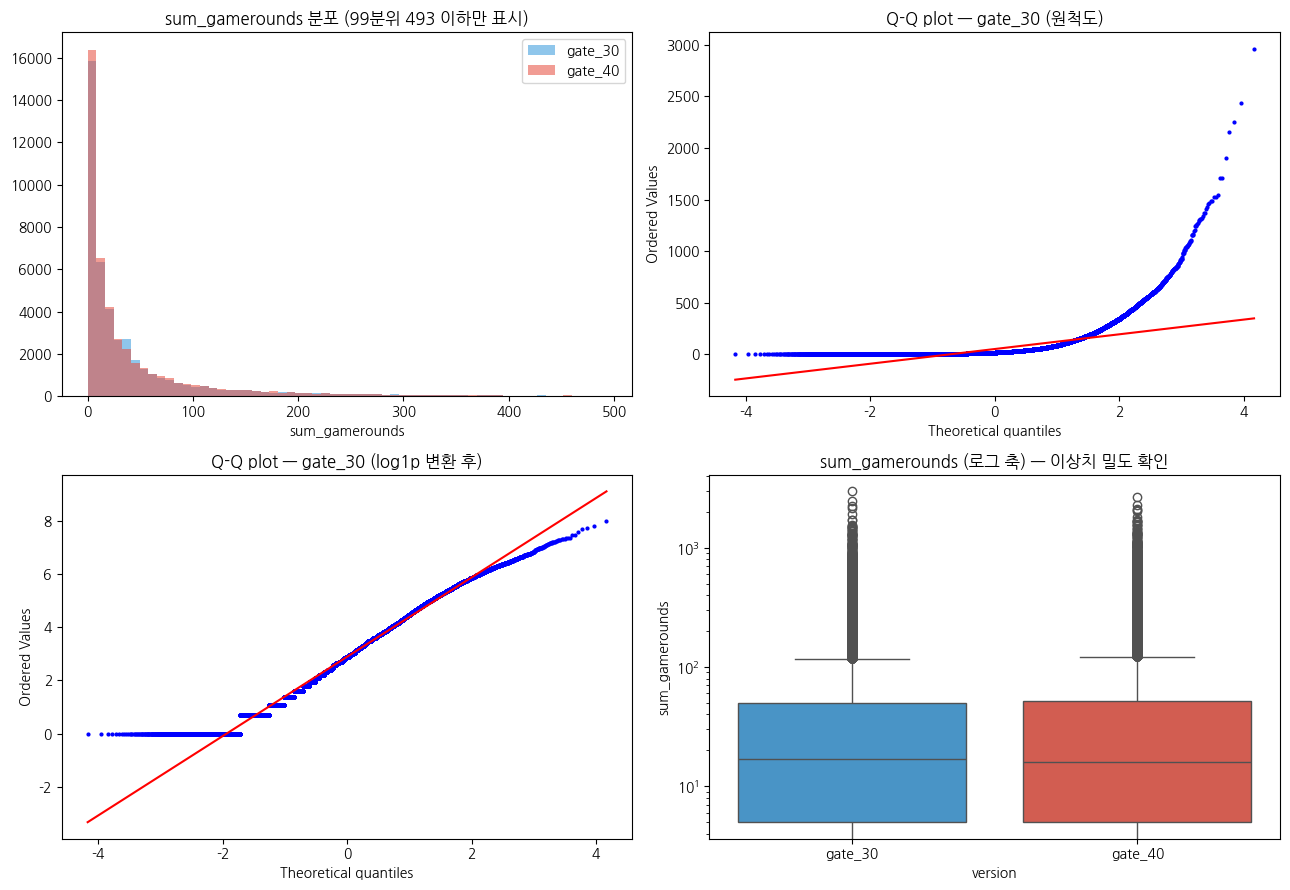


  0라운드 비중: gate_30 4.33%  |  gate_40 4.52%
  → 0에 질량이 몰린 극단 우편향 분포. 로그 변환으로도 0 덩어리는 해결되지 않는다.


In [3]:
# ============================================================
# 단계 3 — 검정 선택을 위한 가정 진단
# ============================================================
from scipy import stats

TARGET   = 'retention_7'
A, B     = 'gate_30', 'gate_40'
ALPHA    = 0.05

# ── 3-1. 주 지표(retention_7): 비율 지표의 정규근사 조건 ─────────
print("=" * 62)
print("[3-1] 주 지표 retention_7 — 비율 · 2집단")
print("=" * 62)

tab = df.groupby('version')[TARGET].agg(n='count', success='sum')
tab['failure'] = tab['n'] - tab['success']
tab['rate']    = tab['success'] / tab['n']
print(tab.assign(rate=lambda d: (d['rate']*100).round(3).astype(str) + '%').to_string())

# 정규근사 조건: 각 셀의 기대 성공/실패 수가 모두 충분히 큰가 (통상 ≥ 10)
min_cell = min(tab['success'].min(), tab['failure'].min())
print(f"\n  가장 작은 셀 도수 = {min_cell:,}  (기준 ≥ 10)")
print(f"  → 정규근사 조건 {'충족 ✅' if min_cell >= 10 else '위반 ❌ (Fisher 정확검정 필요)'}")
print("  → 표본이 매우 커서 z-근사와 카이제곱이 사실상 동일한 결과를 준다.")
print("    (χ² 통계량 = z² 관계) 따라서 어느 쪽을 써도 되지만,")
print("    비율 차이의 신뢰구간을 자연스럽게 얻을 수 있는 '두 비율 z-검정'을 주 검정으로 쓴다.")

# 참고: 분할표와 카이제곱 기대도수
ct = pd.crosstab(df['version'], df[TARGET])
chi2_ref, p_ref, dof_ref, expected = stats.chi2_contingency(ct, correction=False)
print(f"\n  [참고] 분할표 기대도수 최소값 = {expected.min():,.1f}  (기준 ≥ 5) → 충족")
print(f"  [참고] 카이제곱 독립성 검정: χ²({dof_ref}) = {chi2_ref:.4f}, p = {p_ref:.4f}")

# ── 3-2. 보조 지표(sum_gamerounds): 정규성 · 등분산 진단 ─────────
print("\n" + "=" * 62)
print("[3-2] 보조 지표 sum_gamerounds — 연속형 · 2집단")
print("=" * 62)

ga = df.loc[df['version'] == A, 'sum_gamerounds'].to_numpy()
gb = df.loc[df['version'] == B, 'sum_gamerounds'].to_numpy()

desc = df.groupby('version')['sum_gamerounds'].agg(
    n='count', mean='mean', median='median', std='std',
    skew=lambda s: s.skew(), kurt=lambda s: s.kurt()).round(3)
print(desc.to_string())

print("\n  [정규성] Shapiro-Wilk")
print("   ※ n≈45,000에서는 Shapiro가 아주 미세한 이탈에도 반드시 유의해지므로")
print("     각 군 5,000개 무작위 부표본으로 수행하고, 판단은 시각 진단과 왜도를 함께 본다.")
for name, g in [(A, ga), (B, gb)]:
    sub = RNG.choice(g, size=5000, replace=False)
    W, p_sw = stats.shapiro(sub)
    print(f"   {name}: W = {W:.4f}, p = {p_sw:.3e} → {'정규성 위반' if p_sw < ALPHA else '기각 못함'}")

print("\n  [등분산] Levene (center='median', 비정규에 강건)")
lev_stat, lev_p = stats.levene(ga, gb, center='median')
print(f"   W = {lev_stat:.4f}, p = {lev_p:.4f} → {'등분산 위반' if lev_p < ALPHA else '기각 못함'}")
print(f"   분산비 = {max(ga.var(ddof=1), gb.var(ddof=1)) / min(ga.var(ddof=1), gb.var(ddof=1)):.3f}")

# ── 3-3. 시각 진단 ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) 히스토그램 — 99분위 이하만 표시(꼬리 때문에 형태가 안 보이므로)
cut = df['sum_gamerounds'].quantile(0.99)
for name, g, c in [(A, ga, '#3498DB'), (B, gb, '#E74C3C')]:
    axes[0, 0].hist(g[g <= cut], bins=60, alpha=0.55, label=name, color=c)
axes[0, 0].set_title(f'sum_gamerounds 분포 (99분위 {cut:.0f} 이하만 표시)')
axes[0, 0].set_xlabel('sum_gamerounds'); axes[0, 0].legend()

# (b) Q-Q plot (gate_30)
stats.probplot(ga, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title(f'Q-Q plot — {A} (원척도)')
axes[0, 1].get_lines()[0].set_markersize(2)

# (c) 로그 변환 후 Q-Q — 변환으로 해결되는지 확인
stats.probplot(np.log1p(ga), dist='norm', plot=axes[1, 0])
axes[1, 0].set_title(f'Q-Q plot — {A} (log1p 변환 후)')
axes[1, 0].get_lines()[0].set_markersize(2)

# (d) 박스플롯
sns.boxplot(data=df, x='version', y='sum_gamerounds', ax=axes[1, 1],
            palette={A: '#3498DB', B: '#E74C3C'}, hue='version', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('sum_gamerounds (로그 축) — 이상치 밀도 확인')

plt.tight_layout(); plt.show()

print(f"\n  0라운드 비중: {A} {(ga==0).mean()*100:.2f}%  |  {B} {(gb==0).mean()*100:.2f}%")
print("  → 0에 질량이 몰린 극단 우편향 분포. 로그 변환으로도 0 덩어리는 해결되지 않는다.")

## 3. 검정 선택과 근거

### 3.1 진단 결과 요약

**주 지표 `retention_7` (비율 · 2집단)**

| version | n | 성공 | 실패 | 비율 |
|---|---|---|---|---|
| gate_30 (A) | 44,699 | 8,501 | 36,198 | 19.018% |
| gate_40 (B) | 45,489 | 8,279 | 37,210 | 18.200% |

- 최소 셀 도수 8,279, 분할표 기대도수 최소 8,316.5 → 정규근사 조건 충족(기준 ≥ 10, ≥ 5)

**보조 지표 `sum_gamerounds` (연속형 · 2집단)**

| version | n | 평균 | 중앙값 | 표준편차 | 왜도 | 첨도 |
|---|---|---|---|---|---|---|
| gate_30 | 44,699 | 51.342 | 17.0 | 102.058 | 5.940 | 67.563 |
| gate_40 | 45,489 | 51.299 | 16.0 | 103.294 | 5.967 | 63.106 |

- 정규성: Shapiro-Wilk(각 군 5,000 부표본) W = 0.452 / 0.468, p < 1e-80 → **심각한 위반**
- 등분산: Levene(median) W = 0.075, **p = 0.784 → 등분산은 성립**, 분산비 1.024
- 0라운드 비중 약 4.4% → 0에 점질량이 있는 극단 우편향
- log1p 변환 시 Q-Q 중앙부는 크게 개선되나 0 점질량으로 인한 좌측 계단이 잔존

### 3.2 나는 어떤 검정을 골랐고, 왜인가

**주 지표에 대해 나는 두 비율 z-검정(two-proportion z-test)을 골랐다.** 왜냐하면 `retention_7`은 각 유저가 "7일 후 재접속했다/안 했다"로만 기록되는 이항(binary) 결과이고 비교 집단이 정확히 2개이므로, 검정 대상이 평균이 아니라 **모비율의 차이**이기 때문이다. 이때 정규근사가 정당한지가 유일한 가정 문제인데, 가장 작은 셀 도수가 8,279명이고 분할표 기대도수 최소값이 8,316.5로 통상 기준(각 10 이상, 기대도수 5 이상)을 3자리 수 이상 여유롭게 넘겨 이항분포의 정규근사가 안전하게 성립한다. 따라서 소표본용 Fisher 정확검정은 불필요하고(계산비용만 커진다), 연속성 보정도 이 표본 크기에서는 결과를 바꾸지 않는다. 카이제곱 독립성 검정도 동일하게 타당하지만(실제로 χ²(1) = 9.969, p = 0.0016이며 이론적으로 χ² = z² 관계가 성립한다) **카이제곱은 "연관이 있다"만 말해주고 차이의 크기와 방향, 그리고 그 차이의 신뢰구간을 주지 않는다.** 이 과제는 점추정·95% 신뢰구간·효과 크기를 함께 보고하도록 요구하므로, 비율 차이(p_B − p_A)를 직접 추정하고 그 구간을 얻을 수 있는 z-검정 틀을 주 검정으로 채택했다.

**보조 지표 `sum_gamerounds`에 대해서는 Mann-Whitney U 검정을 주로 쓰고, 부트스트랩을 병행한다.** 왜냐하면 이 지표는 연속형·2집단이지만 정규성이 심각하게 깨졌기 때문이다(왜도 약 5.94, 첨도 약 67.6, Shapiro p < 1e-80). 특히 문제는 첨도 67.6이 뜻하는 극단 꼬리다. 표본이 크므로 중심극한정리로 평균의 표집분포는 결국 정규에 근사하지만, 이런 두꺼운 꼬리에서는 수렴이 느리고 **소수의 관측치가 평균을 지배한다** — 실제로 단계 1에서 발견한 단 1개의 값(49,854라운드)이 2등(2,961)의 17배였다. 두 군의 평균이 51.342 vs 51.299로 사실상 동일한데 중앙값은 17 vs 16으로 갈리는 것이 그 증거다. 평균 비교는 "전형적인 유저에게 무슨 일이 일어났는가"에 답하지 못한다. 흥미롭게도 등분산은 성립하므로(Levene p = 0.784) 이는 Welch 보정으로 해결될 문제가 아니라 **분포 형태 자체의 문제**다. log1p 변환도 검토했으나 0라운드 유저 4.4%가 만드는 점질량이 남고, 무엇보다 변환 후 t-검정은 기하평균을 비교하는 것이 되어 "평균 플레이 라운드 수"라는 원래 질문과 지표 정의가 달라진다. 따라서 분포 가정을 요구하지 않는 순위 기반 Mann-Whitney U를 선택했다. 다만 Mann-Whitney는 **차이의 크기에 대한 신뢰구간을 주지 않으므로**, 평균/중앙값 차이의 구간 추정은 분포 가정이 필요 없는 부트스트랩으로 별도로 구한다(단계 5).

### 3.3 검정 요약표

| 지표 | 유형 | 집단 | 가정 상태 | 채택 검정 | 효과 크기 |
|---|---|---|---|---|---|
| `retention_7` (주) | 비율 | 2 | 정규근사 충족 | **두 비율 z-검정** | 절대차(%p) + 상대차 + Cohen's h |
| `retention_1` (보조) | 비율 | 2 | 정규근사 충족 | 두 비율 z-검정 (탐색적) | 절대차 + 상대차 |
| `sum_gamerounds` (보조) | 연속 | 2 | 정규성 위반, 등분산 OK | **Mann-Whitney U** + 부트스트랩 | rank-biserial r |

### 3.4 검토했으나 채택하지 않은 것

| 검정 | 배제 이유 |
|---|---|
| Fisher 정확검정 | 최소 셀 8,279로 소표본이 아님. 정규근사가 충분히 정확 |
| 2표본 t-검정 (`sum_gamerounds`) | 첨도 67.6의 극단 꼬리에서 평균이 소수 관측치에 지배됨. 단계 5에서 참고용으로 비교만 수행 |
| Welch t-검정 | 등분산이 성립(p = 0.784)하므로 등분산 위반 대책은 문제 해결과 무관 |
| log 변환 후 t-검정 | 0 점질량 잔존 + 기하평균 비교로 지표 정의가 변질됨 |
| 일원 ANOVA | 비교 집단이 2개뿐이므로 불필요(2집단 ANOVA는 t-검정과 동일) |

★ 주 지표 | 7일 잔존율  (retention_7)
  gate_30 (A, 대조) :  19.018%   [18.657, 19.385]   8,501/44,699
  gate_40 (B, 실험) :  18.200%   [17.848, 18.557]   8,279/45,489

  ① 점추정  (B − A)
       절대 차이 : -0.818%p
       상대 차이 : -4.30%   (0.9570배)
  ② 95% 신뢰구간 (절대 차이, Newcombe)
       [-1.326%p, -0.310%p]   → 0 미포함 ✅ 유의
  ③ 효과 크기
       Cohen's h  = -0.0210   (0.2 미만이면 매우 작음)
       Cramér's V = 0.0105   (0.1 미만이면 무시할 수준의 연관)

  검정: 두 비율 z-검정  z = -3.1574,  p = 0.0016  (α = 0.05, 양측)
  판정: H0 기각 → 두 군의 잔존율은 다르다

  보조(탐색적) | 1일 잔존율  (retention_1)
  gate_30 (A, 대조) :  44.820%   [44.359, 45.281]   20,034/44,699
  gate_40 (B, 실험) :  44.228%   [43.772, 44.685]   20,119/45,489

  ① 점추정  (B − A)
       절대 차이 : -0.592%p
       상대 차이 : -1.32%   (0.9868배)
  ② 95% 신뢰구간 (절대 차이, Newcombe)
       [-1.240%p, +0.057%p]   → 0 포함 ❌ 불충분
  ③ 효과 크기
       Cohen's h  = -0.0119   (0.2 미만이면 매우 작음)
       Cramér's V = 0.0060   (0.1 미만이면 무시할 수준의 연관)

  검정: 두 비율 z-검정  z = -1.7871,  p = 0.0739  (α = 0.05, 양측)
  판정: H0 기각 실패 → 차

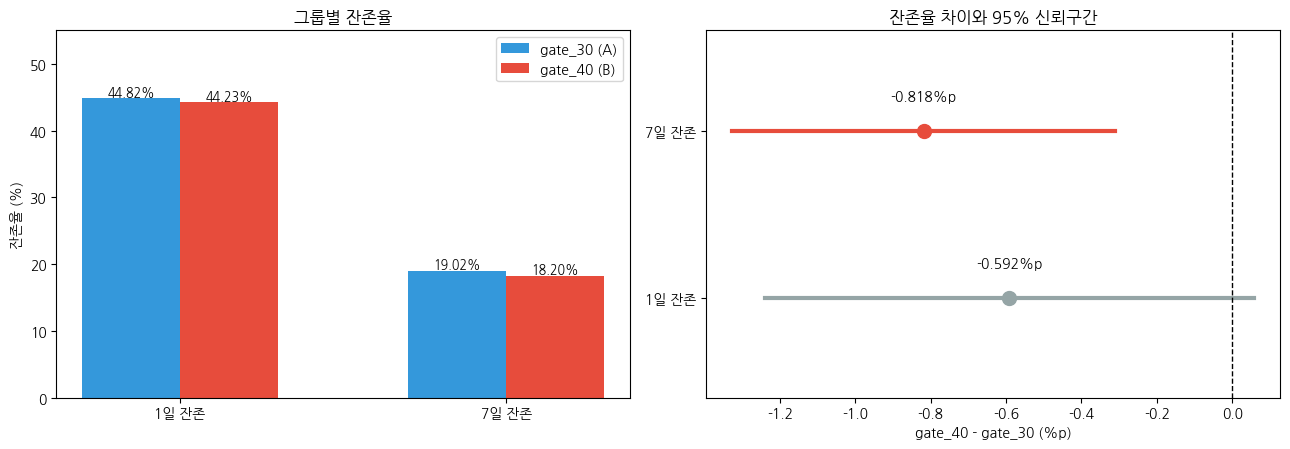

In [4]:
# ============================================================
# 단계 4 — 검정 수행 · 점추정 / 95% CI / 효과 크기
# ============================================================
from statsmodels.stats.proportion import (
    proportions_ztest, proportion_confint, proportion_effectsize,
    confint_proportions_2indep
)

ALPHA = 0.05

def test_proportion_metric(data, metric, label, primary=False):
    """비율 지표 2집단 비교: 점추정 · 95% CI · 효과 크기를 함께 반환."""
    g = data.groupby('version')[metric].agg(n='count', s='sum')
    nA, sA = int(g.loc[A, 'n']), int(g.loc[A, 's'])
    nB, sB = int(g.loc[B, 'n']), int(g.loc[B, 's'])
    pA, pB = sA / nA, sB / nB

    # ① 점추정 — 차이는 (실험군 B − 대조군 A) 방향으로 통일
    diff_abs = pB - pA                     # 절대 차이 (비율)
    diff_rel = diff_abs / pA               # 상대 차이 (배수)

    # ② 95% 신뢰구간
    ciA = proportion_confint(sA, nA, alpha=ALPHA, method='wilson')
    ciB = proportion_confint(sB, nB, alpha=ALPHA, method='wilson')
    ci_lo, ci_hi = confint_proportions_2indep(sB, nB, sA, nA,
                                              method='newcomb', compare='diff', alpha=ALPHA)

    # ③ 검정 + 효과 크기
    z, p = proportions_ztest([sB, sA], [nB, nA])          # pooled z-test, 양측
    h = proportion_effectsize(pB, pA)                      # Cohen's h
    chi2_, p_chi, _, _ = stats.chi2_contingency(
        [[sA, nA - sA], [sB, nB - sB]], correction=False)
    cramers_v = np.sqrt(chi2_ / (nA + nB))                 # 2×2에서는 φ와 동일

    tag = "★ 주 지표" if primary else "  보조(탐색적)"
    print("=" * 66)
    print(f"{tag} | {label}  ({metric})")
    print("=" * 66)
    print(f"  gate_30 (A, 대조) : {pA*100:7.3f}%   [{ciA[0]*100:.3f}, {ciA[1]*100:.3f}]   {sA:,}/{nA:,}")
    print(f"  gate_40 (B, 실험) : {pB*100:7.3f}%   [{ciB[0]*100:.3f}, {ciB[1]*100:.3f}]   {sB:,}/{nB:,}")
    print(f"\n  ① 점추정  (B − A)")
    print(f"       절대 차이 : {diff_abs*100:+.3f}%p")
    print(f"       상대 차이 : {diff_rel*100:+.2f}%   ({(1+diff_rel):.4f}배)")
    print(f"  ② 95% 신뢰구간 (절대 차이, Newcombe)")
    print(f"       [{ci_lo*100:+.3f}%p, {ci_hi*100:+.3f}%p]"
          f"   → 0 {'미포함 ✅ 유의' if ci_lo * ci_hi > 0 else '포함 ❌ 불충분'}")
    print(f"  ③ 효과 크기")
    print(f"       Cohen's h  = {h:+.4f}   (0.2 미만이면 매우 작음)")
    print(f"       Cramér's V = {cramers_v:.4f}   (0.1 미만이면 무시할 수준의 연관)")
    print(f"\n  검정: 두 비율 z-검정  z = {z:+.4f},  p = {p:.4f}  (α = {ALPHA}, 양측)")
    print(f"  판정: H0 {'기각 → 두 군의 잔존율은 다르다' if p < ALPHA else '기각 실패 → 차이의 증거 부족'}")
    return dict(metric=metric, pA=pA, pB=pB, diff_abs=diff_abs, diff_rel=diff_rel,
                ci=(ci_lo, ci_hi), z=z, p=p, h=h, v=cramers_v, nA=nA, nB=nB)

# ── 4-1. 주 지표 ────────────────────────────────────────────
res7 = test_proportion_metric(df, 'retention_7', '7일 잔존율', primary=True)

# ── 4-2. 보조 지표 (결론의 근거로 쓰지 않음) ─────────────────
print()
res1 = test_proportion_metric(df, 'retention_1', '1일 잔존율')

# ── 4-3. 보조 지표: sum_gamerounds (Mann-Whitney U) ─────────
print()
print("=" * 66)
print("  보조(탐색적) | 총 플레이 라운드 수  (sum_gamerounds)")
print("=" * 66)
U, p_mw = stats.mannwhitneyu(gb, ga, alternative='two-sided')   # (B, A) 순서
n1, n2 = len(gb), len(ga)
rb = 2 * U / (n1 * n2) - 1        # rank-biserial correlation
cles = U / (n1 * n2)              # common language effect size

print(f"  중앙값 : A {np.median(ga):.1f}  vs  B {np.median(gb):.1f}   (차이 {np.median(gb)-np.median(ga):+.1f})")
print(f"  평균   : A {ga.mean():.3f}  vs  B {gb.mean():.3f}   (차이 {gb.mean()-ga.mean():+.3f})")
print(f"\n  Mann-Whitney U = {U:,.0f},  p = {p_mw:.4f}")
print(f"  효과 크기: rank-biserial r = {rb:+.4f}   (|r| < 0.1 → 무시할 수준)")
print(f"             CLES = {cles:.4f}  → 무작위로 뽑은 B 유저가 A 유저보다 많이 플레이할 확률")
print(f"  판정: H0 {'기각' if p_mw < ALPHA else '기각 실패'}  ※ 탐색적 — 의사결정 근거로 쓰지 않음")

# ── 4-4. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (좌) 두 지표의 잔존율 + 95% CI
labels, xs = ['1일 잔존', '7일 잔존'], np.arange(2)
for k, (nm, key, c, off) in enumerate([('gate_30 (A)', 'pA', '#3498DB', -0.15),
                                       ('gate_40 (B)', 'pB', '#E74C3C',  0.15)]):
    vals = [res1[key] * 100, res7[key] * 100]
    axes[0].bar(xs + off, vals, width=0.3, label=nm, color=c)
    for x, v in zip(xs + off, vals):
        axes[0].text(x, v + 0.4, f'{v:.2f}%', ha='center', fontsize=9)
axes[0].set_xticks(xs); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('잔존율 (%)'); axes[0].set_ylim(0, 55)
axes[0].set_title('그룹별 잔존율'); axes[0].legend()

# (우) 차이의 점추정 + 95% CI (forest plot)
for i, (res, nm) in enumerate([(res1, '1일 잔존'), (res7, '7일 잔존')]):
    lo, hi = res['ci'][0] * 100, res['ci'][1] * 100
    pt = res['diff_abs'] * 100
    col = '#E74C3C' if lo * hi > 0 else '#95A5A6'
    axes[1].plot([lo, hi], [i, i], color=col, lw=3)
    axes[1].plot(pt, i, 'o', color=col, ms=10)
    axes[1].text(pt, i + 0.18, f'{pt:+.3f}%p', ha='center', fontsize=10)
axes[1].axvline(0, ls='--', color='black', lw=1)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['1일 잔존', '7일 잔존'])
axes[1].set_xlabel('gate_40 - gate_30 (%p)'); axes[1].set_ylim(-0.6, 1.6)
axes[1].set_title('잔존율 차이와 95% 신뢰구간')

plt.tight_layout(); plt.show()

✅ 상태 확인: df 90,188행 (정제됨) / df_with_outlier 90,189행 (원본)

[5-1] 이상치 처리 방식별 민감도  —  sum_gamerounds (Mann-Whitney U)
                  처리     n   평균A  평균B  중앙A  중앙B   MW p  판정
     ① 원본 (아무것도 안 함) 90189 52.46 51.3 17.0 16.0 0.0502 비유의
② 사전 기준 제거 (>40,000) 90188 51.34 51.3 17.0 16.0 0.0509 비유의
    ③ 사후 트리밍 (≤ p99) 89291 44.66 44.4 16.0 16.0 0.0479  유의

  ※ p99 = 493라운드, ③에서 추가로 잘려나간 유저 = 897명
  ⚠️ ①→③ 순서로 p가 0.05를 가로지른다면, 이 지표의 '유의성'은
     데이터가 아니라 분석자의 정제 선택이 만들어낸 것이다.
     ③은 결과를 본 뒤 기준을 바꾼 것이므로 근거로 쓸 수 없다 — 취약성 시연 목적일 뿐.

[5-2] 방법 비교  —  sum_gamerounds (정제 데이터 기준)
  (순열검정 10,000회 완료 — 30.9초)
  (부트스트랩 10,000회 ×2 완료 — 총 65.0초)

            방법       가정     비교대상    추정치         95% CI       p
 t-검정 (pooled) 정규성 ❌ 위반       평균 -0.043              —  0.9495
    Welch t-검정 정규성 ❌ 위반       평균 -0.043              —  0.9495
Mann-Whitney U  가정 없음 ✅ 순위(확률우위)      —              —  0.0509
    순열검정 (평균차)  가정 없음 ✅       평균 -0.043              —   0.951
   부트스트랩 (평균차)  가정 없음 ✅       평균 -0.037 [-1.37, +1.

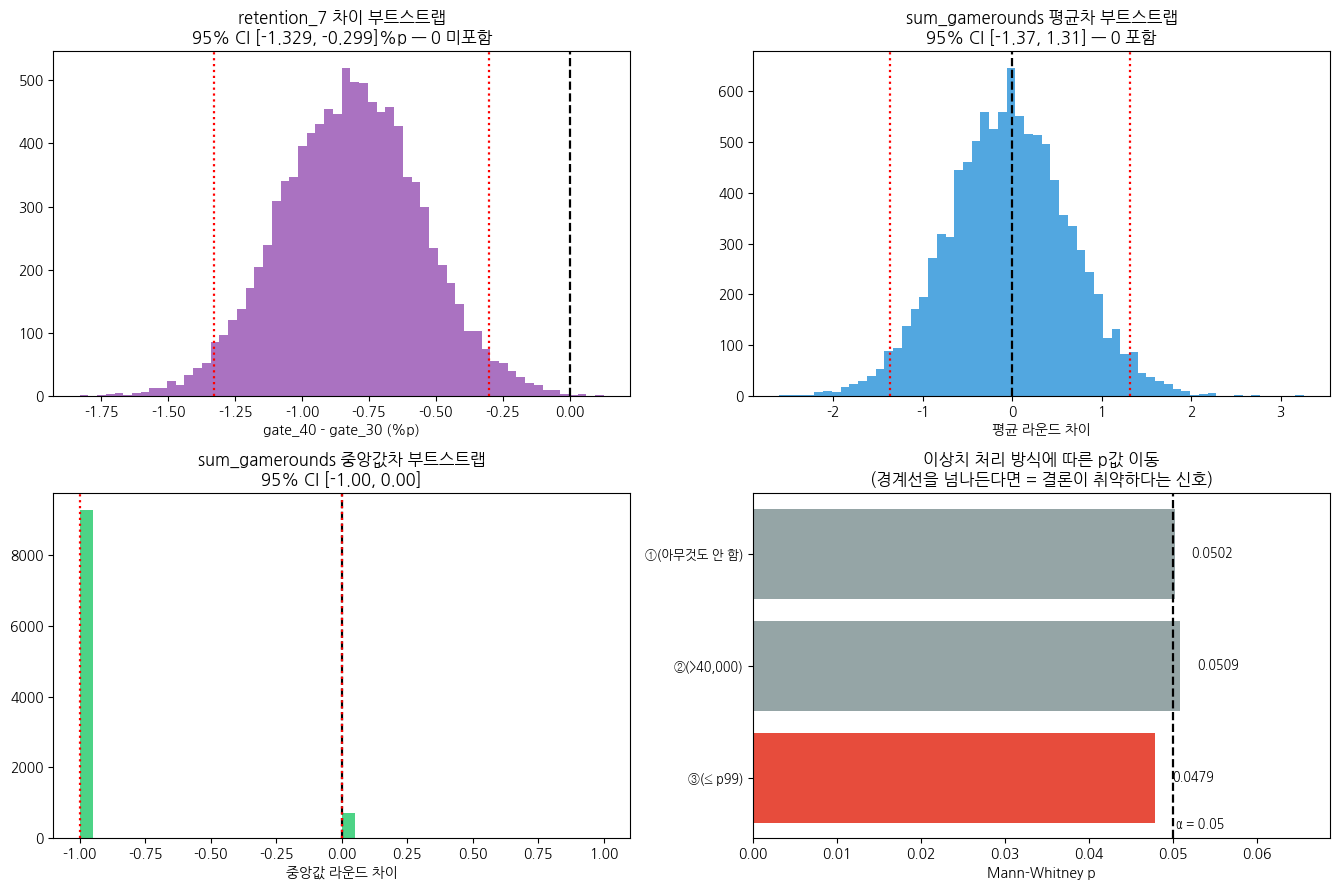

In [5]:
# ============================================================
# 단계 5 (선택 B) — 가정이 깨졌을 때: 방법 비교와 강건성 검증
# ============================================================
import time

# ── 상태 검증 (단계 1 정제가 유효한지 확인) ──────────────────
assert len(df) == 90188, (
    f"df가 정제 상태가 아닙니다 (현재 {len(df):,}행). "
    "런타임 → 세션 다시 시작 및 모두 실행 후 재시도하세요.")
RNG = np.random.default_rng(SEED)   # 5단계 진입 시 난수 상태 리셋 (셀 단위 재현성)
print(f"✅ 상태 확인: df {len(df):,}행 (정제됨) / df_with_outlier {len(df_with_outlier):,}행 (원본)\n")

N_BOOT, N_PERM = 10000, 10000

# ── 유틸 ────────────────────────────────────────────────────
def boot_diff(a, b, stat, n_boot=N_BOOT, batch=200, rng=RNG):
    """비모수 부트스트랩: stat(B) - stat(A)의 표집분포. 분포 가정 없음."""
    na, nb = len(a), len(b)
    out = np.empty(n_boot)
    for i in range(0, n_boot, batch):
        k = min(batch, n_boot - i)
        sa = a[rng.integers(0, na, size=(k, na))]
        sb = b[rng.integers(0, nb, size=(k, nb))]
        out[i:i+k] = stat(sb, axis=1) - stat(sa, axis=1)
    return out

def perm_test_mean(a, b, n_perm=N_PERM, rng=RNG):
    """순열검정: H0(두 군 분포 동일) 하에서 라벨을 섞어 평균차 귀무분포 생성."""
    pooled, na = np.concatenate([a, b]), len(a)
    obs = b.mean() - a.mean()
    cnt = 0
    for _ in range(n_perm):
        p_ = rng.permutation(pooled)
        if abs(p_[na:].mean() - p_[:na].mean()) >= abs(obs):
            cnt += 1
    return obs, (cnt + 1) / (n_perm + 1)      # +1 보정: p=0 방지

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (b.mean() - a.mean()) / sp

# ── 5-1. 이상치 처리 방식에 따라 결론이 바뀌는가 ─────────────
print("=" * 74)
print("[5-1] 이상치 처리 방식별 민감도  —  sum_gamerounds (Mann-Whitney U)")
print("=" * 74)

p99 = df['sum_gamerounds'].quantile(0.99)
variants = {
    '① 원본 (아무것도 안 함)':        df_with_outlier,
    '② 사전 기준 제거 (>40,000)':     df,
    '③ 사후 트리밍 (≤ p99)':          df[df['sum_gamerounds'] <= p99],
}
rows = []
for name, d in variants.items():
    x = d.loc[d['version'] == A, 'sum_gamerounds'].to_numpy()
    y = d.loc[d['version'] == B, 'sum_gamerounds'].to_numpy()
    U_, p_ = stats.mannwhitneyu(y, x, alternative='two-sided')
    rows.append({
        '처리': name, 'n': len(d),
        '평균A': round(x.mean(), 2), '평균B': round(y.mean(), 2),
        '중앙A': np.median(x), '중앙B': np.median(y),
        'MW p': round(p_, 4),
        '판정': '유의' if p_ < ALPHA else '비유의',
    })
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
print(f"\n  ※ p99 = {p99:.0f}라운드, ③에서 추가로 잘려나간 유저 = {len(df) - len(variants['③ 사후 트리밍 (≤ p99)']):,}명")
print("  ⚠️ ①→③ 순서로 p가 0.05를 가로지른다면, 이 지표의 '유의성'은")
print("     데이터가 아니라 분석자의 정제 선택이 만들어낸 것이다.")
print("     ③은 결과를 본 뒤 기준을 바꾼 것이므로 근거로 쓸 수 없다 — 취약성 시연 목적일 뿐.")

# ── 5-2. 같은 데이터, 다른 검정: 방법 간 일치도 ──────────────
print("\n" + "=" * 74)
print("[5-2] 방법 비교  —  sum_gamerounds (정제 데이터 기준)")
print("=" * 74)
t0 = time.time()

t_stat,  p_t  = stats.ttest_ind(gb, ga, equal_var=True)    # 등분산 성립하므로 pooled
w_stat,  p_w  = stats.ttest_ind(gb, ga, equal_var=False)   # Welch (참고)
U_stat,  p_mw = stats.mannwhitneyu(gb, ga, alternative='two-sided')
obs_diff, p_perm = perm_test_mean(ga, gb)
print(f"  (순열검정 {N_PERM:,}회 완료 — {time.time()-t0:.1f}초)")

bd_mean = boot_diff(ga, gb, np.mean)
bd_med  = boot_diff(ga, gb, np.median)
ci_mean = np.percentile(bd_mean, [2.5, 97.5])
ci_med  = np.percentile(bd_med,  [2.5, 97.5])
print(f"  (부트스트랩 {N_BOOT:,}회 ×2 완료 — 총 {time.time()-t0:.1f}초)\n")

comp = pd.DataFrame([
    {'방법': 't-검정 (pooled)',     '가정': '정규성 ❌ 위반', '비교대상': '평균',
     '추정치': round(gb.mean()-ga.mean(), 3), '95% CI': '—',                       'p': round(p_t, 4)},
    {'방법': 'Welch t-검정',        '가정': '정규성 ❌ 위반', '비교대상': '평균',
     '추정치': round(gb.mean()-ga.mean(), 3), '95% CI': '—',                       'p': round(p_w, 4)},
    {'방법': 'Mann-Whitney U',      '가정': '가정 없음 ✅',  '비교대상': '순위(확률우위)',
     '추정치': '—',                            '95% CI': '—',                       'p': round(p_mw, 4)},
    {'방법': '순열검정 (평균차)',    '가정': '가정 없음 ✅',  '비교대상': '평균',
     '추정치': round(obs_diff, 3),             '95% CI': '—',                       'p': round(p_perm, 4)},
    {'방법': '부트스트랩 (평균차)',  '가정': '가정 없음 ✅',  '비교대상': '평균',
     '추정치': round(bd_mean.mean(), 3),
     '95% CI': f'[{ci_mean[0]:+.2f}, {ci_mean[1]:+.2f}]',                           'p': '—'},
    {'방법': '부트스트랩 (중앙값차)','가정': '가정 없음 ✅',  '비교대상': '중앙값',
     '추정치': round(bd_med.mean(), 3),
     '95% CI': f'[{ci_med[0]:+.2f}, {ci_med[1]:+.2f}]',                             'p': '—'},
])
print(comp.to_string(index=False))
print(f"\n  Cohen's d = {cohens_d(ga, gb):+.5f}   (참고: 정규성 위반 하에서는 해석에 주의)")
# 부등호를 <= 로 (경계값 0.00을 '포함'으로 처리)
print(f"  평균차 CI가 0 포함: {'예' if ci_mean[0] <= 0 <= ci_mean[1] else '아니오'}"
      f"  |  중앙값차 CI가 0 포함: {'예' if ci_med[0] <= 0 <= ci_med[1] else '아니오'}")

vals, cnts = np.unique(bd_med, return_counts=True)
print("\n  [중앙값 차이(B-A) 부트스트랩 분포]")
for v, c in zip(vals, cnts):
    print(f"     {v:+.0f}라운드 : {c/len(bd_med)*100:6.2f}%")
print(f"     P(차이 < 0) = {(bd_med < 0).mean()*100:.2f}%"
      f"   |   P(차이 = 0) = {(bd_med == 0).mean()*100:.2f}%")
print("  → sum_gamerounds가 정수라 중앙값 차이가 -1 / 0 / +1 세 값만 갖는다.")
print("     이런 이산 통계량에 백분위수 CI는 부적절하므로,")
print("     '재표집의 대부분에서 B의 중앙값이 1라운드 낮았다'로 보고한다.")

# ── 5-3. 주 지표 독립 검증: 부트스트랩 vs z-검정 ─────────────
print("\n" + "=" * 74)
print("[5-3] 주 지표 retention_7 — 공식 기반 z-검정을 부트스트랩으로 독립 검증")
print("=" * 74)
# 베르누이 표본의 비모수 부트스트랩은 Binomial(n, p̂)/n 과 정확히 동일하므로 이를 이용
nA_, nB_ = res7['nA'], res7['nB']
pA_, pB_ = res7['pA'], res7['pB']
bd_r7 = RNG.binomial(nB_, pB_, N_BOOT)/nB_ - RNG.binomial(nA_, pA_, N_BOOT)/nA_
ci_r7 = np.percentile(bd_r7, [2.5, 97.5])

print(f"  z-검정      CI : [{res7['ci'][0]*100:+.3f}%p, {res7['ci'][1]*100:+.3f}%p]   (Newcombe, 공식 기반)")
print(f"  부트스트랩  CI : [{ci_r7[0]*100:+.3f}%p, {ci_r7[1]*100:+.3f}%p]   (재표집 {N_BOOT:,}회, 가정 없음)")
print(f"  부트스트랩 표본 중 차이 ≥ 0 인 비율 : {(bd_r7 >= 0).mean()*100:.3f}%")
print(f"  → 두 방법이 {'일치 ✅ 결론이 방법 선택에 의존하지 않음' if (ci_r7[1] < 0) == (res7['ci'][1] < 0) else '불일치 ⚠️'}")

# ── 5-4. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))

axes[0,0].hist(bd_r7*100, bins=60, color='#9B59B6', alpha=.85)
for v, ls, c in [(0, '--', 'black'), (ci_r7[0]*100, ':', 'red'), (ci_r7[1]*100, ':', 'red')]:
    axes[0,0].axvline(v, ls=ls, color=c, lw=1.6)
axes[0,0].set_title(f'retention_7 차이 부트스트랩\n95% CI [{ci_r7[0]*100:.3f}, {ci_r7[1]*100:.3f}]%p — 0 미포함')
axes[0,0].set_xlabel('gate_40 - gate_30 (%p)')

axes[0,1].hist(bd_mean, bins=60, color='#3498DB', alpha=.85)
for v, ls, c in [(0, '--', 'black'), (ci_mean[0], ':', 'red'), (ci_mean[1], ':', 'red')]:
    axes[0,1].axvline(v, ls=ls, color=c, lw=1.6)
axes[0,1].set_title(f'sum_gamerounds 평균차 부트스트랩\n95% CI [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}] — 0 포함')
axes[0,1].set_xlabel('평균 라운드 차이')

axes[1,0].hist(bd_med, bins=40, color='#2ECC71', alpha=.85)
for v, ls, c in [(0, '--', 'black'), (ci_med[0], ':', 'red'), (ci_med[1], ':', 'red')]:
    axes[1,0].axvline(v, ls=ls, color=c, lw=1.6)
axes[1,0].set_title(f'sum_gamerounds 중앙값차 부트스트랩\n95% CI [{ci_med[0]:.2f}, {ci_med[1]:.2f}]')
axes[1,0].set_xlabel('중앙값 라운드 차이')

names = [r['처리'].split(' ')[0] + r['처리'][r['처리'].find('('):] for r in rows]
pvals = [r['MW p'] for r in rows]
cols  = ['#E74C3C' if p < ALPHA else '#95A5A6' for p in pvals]
axes[1,1].barh(range(3), pvals, color=cols)
axes[1,1].axvline(ALPHA, ls='--', color='black', lw=1.6)
axes[1,1].text(ALPHA, 2.45, ' α = 0.05', fontsize=9)
axes[1,1].set_yticks(range(3)); axes[1,1].set_yticklabels(names, fontsize=9)
for i, p in enumerate(pvals):
    axes[1,1].text(p + .002, i, f'{p:.4f}', va='center', fontsize=9)
axes[1,1].set_xlim(0, max(pvals)*1.35)
axes[1,1].set_title('이상치 처리 방식에 따른 p값 이동\n(경계선을 넘나든다면 = 결론이 취약하다는 신호)')
axes[1,1].set_xlabel('Mann-Whitney p')
axes[1,1].invert_yaxis()

plt.tight_layout(); plt.show()

## 4. 검정 결과

### 4.1 주 지표 — 7일 잔존율 (사전 선언된 유일한 의사결정 근거)

| 그룹 | n | 잔존 | 잔존율 | 95% CI (Wilson) |
|---|---|---|---|---|
| gate_30 (A, 대조) | 44,699 | 8,501 | **19.018%** | [18.657, 19.385] |
| gate_40 (B, 실험) | 45,489 | 8,279 | **18.200%** | [17.848, 18.557] |

**3종 세트**

| | 값 |
|---|---|
| ① 점추정 (B − A) | **절대 −0.818%p** / **상대 −4.30%** (0.957배) |
| ② 95% 신뢰구간 | **[−1.326%p, −0.310%p]** — 0 미포함 |
| ③ 효과 크기 | Cohen's h = −0.0210, Cramér's V = 0.0105 |

**검정:** 두 비율 z-검정, z = −3.157, **p = 0.0016** (α = 0.05, 양측) → **H₀ 기각**

> **보고 문장**
> 관문을 레벨 40으로 미룬 그룹의 7일 잔존율이 더 낮았다(18.20% vs 19.02%).
> **−0.818%p (상대 −4.30%), 95% CI [−1.326, −0.310]%p, z = −3.16, p = .0016, Cohen's h = −0.021**

**방향에 대한 주의:** 제품 가설은 "관문을 미루면 잔존율이 오른다"였으나 결과는 **반대 방향**이다. 단계 2에서 양측 검정으로 사전 확정했기에 이 방향을 검출할 수 있었다. 단측(B > A)이었다면 이 결과는 구조적으로 관측 불가능했다.

**효과 크기 해석 — 두 척도가 충돌한다:**
- Cohen 관례 기준으로는 h = 0.021이 "무시할 수준"이다.
- 그러나 Cohen의 기준선은 심리학 실험 관행에서 온 일반값이며, **모바일 게임 잔존율 맥락에서 상대 4.3% 하락은 작지 않다.** DAU 100만 규모라면 7일차에 약 8,200명이 추가 이탈하는 크기다.
- 절대차(0.82%p)만 쓰면 과소평가되고 상대차(4.3%)만 쓰면 과대평가된다. 둘 다 적는 이유다.
- **다만 크기 해석과 무관하게 부호는 음수다.** 도입 근거가 "잔존율 개선"이었으므로, 크기 논쟁 이전에 근거 자체가 성립하지 않는다.

### 4.2 보조 지표 (탐색적 — 의사결정 근거로 사용하지 않음)

| 지표 | A | B | 절대차 | 상대차 | 95% CI | p | 판정 |
|---|---|---|---|---|---|---|---|
| `retention_1` | 44.820% | 44.228% | −0.592%p | −1.32% | [−1.240, +0.057]%p | .0739 | 증거 부족 |
| `sum_gamerounds` (중앙값) | 17.0 | 16.0 | −1.0 | — | — | .0509 (MW) | 증거 부족 |

`retention_1`은 **"차이가 없다"가 아니라 "차이가 있다는 증거가 부족하다"**로 읽어야 한다. CI가 [−1.240, +0.057]로 0을 포함하지만 대부분이 음수 영역에 있어, 점추정 부호는 주 지표와 일관되게 음수다. 이는 결론의 **정성적 뒷받침**이며 통계적 근거는 아니다.

---

## 5. 한 걸음 더 (선택 B) — 가정이 깨졌을 때

### 5.1 같은 데이터, 다른 검정 — 결론이 0.95와 0.05로 갈린다

`sum_gamerounds`에 대해 6가지 방법을 적용했다.

| 방법 | 가정 | 비교 대상 | 추정치 | 95% CI | p |
|---|---|---|---|---|---|
| t-검정 (pooled) | 정규성 ❌ | 평균 | −0.043 | — | **.9495** |
| Welch t-검정 | 정규성 ❌ | 평균 | −0.043 | — | .9495 |
| 순열검정 (평균차) | 가정 없음 ✅ | 평균 | −0.043 | — | .951 |
| 부트스트랩 (평균차) | 가정 없음 ✅ | 평균 | −0.037 | [−1.37, +1.31] | — |
| **Mann-Whitney U** | 가정 없음 ✅ | 순위 | — | — | **.0509** |
| 부트스트랩 (중앙값차) | 가정 없음 ✅ | 중앙값 | −0.925 | [−1.00, 0.00] | — |

Cohen's d = −0.00042

**해석 — 이것이 이 단계의 핵심 발견이다.** 동일한 데이터에서 p가 0.95와 0.05로 갈렸다. 원인은 정규성 위반 자체가 **아니다**. 결정적 증거는 순열검정(분포 가정 없음)이 p = 0.951로 t-검정과 사실상 같은 답을 냈다는 점이다. 즉 **문제는 "평균이라는 요약통계"에 있다.** 첨도 67.6의 극단 꼬리에서 평균은 소수 헤비 유저에 지배되어 두 군이 51.342 vs 51.299로 거의 같아지지만, 중앙값은 17 vs 16으로 갈린다. 평균 기반 방법은 "전형적 유저에게 일어난 일"을 측정하지 못한다. Welch 보정이 무의미한 것도 같은 이유다 — 등분산은 이미 성립하며(Levene p = .784), 깨진 것은 분포의 **형태**다.

**중앙값 차이의 이산성:** `sum_gamerounds`가 정수이므로 부트스트랩 중앙값 차이는 −1 / 0 / +1 세 값만 갖는다(−1: 92.67%, 0: 7.20%, +1: 0.13%). 백분위수 CI [−1.00, 0.00]은 상한이 정확히 0이어서 0을 **포함**하며, 이런 이산 통계량에 구간 추정을 적용하는 것은 부적절하다. 정확한 보고는 "재표집의 92.7%에서 B의 중앙값이 1라운드 낮았다"이다.

### 5.2 이상치 처리 방식에 따른 민감도

| 처리 | n | 평균 A | 평균 B | 중앙 A | 중앙 B | MW p | 판정 |
|---|---|---|---|---|---|---|---|
| ① 원본 (미처리) | 90,189 | 52.46 | 51.30 | 17.0 | 16.0 | .0502 | 비유의 |
| ② 사전 기준 제거 (>40,000) | 90,188 | 51.34 | 51.30 | 17.0 | 16.0 | .0509 | 비유의 |
| ③ 사후 트리밍 (≤ p99 = 493) | 89,291 | 44.66 | 44.40 | 16.0 | 16.0 | **.0479** | **유의** |

**해석 세 가지:**

1. **"유의성"이 정제 선택으로 만들어졌다.** ③은 897명(1%)을 추가 제거해 p를 0.05 아래로 밀어냈다. 실제 공개된 분석 중에도 ②에서 p = .0509를 확인한 뒤 ③으로 옮겨가 "유의하다"고 결론 낸 사례가 있으나, 이는 **결과를 본 뒤 분석 기준을 변경한 것**으로 사전 등록 원칙 위반이다.

2. **세 p값은 사실상 같은 증거다** (.0479 / .0502 / .0509, 폭 0.003). 판정이 뒤집힌 것은 증거가 변해서가 아니라 0.05라는 임의의 경계선 위에 세 점이 걸쳐 있기 때문이다. **이분법적 유의성 판정의 취약성**을 보여준다.

3. **이상치 1개는 Mann-Whitney를 거의 움직이지 못한다** (.0502 → .0509). 순위 기반 검정은 극단값의 *크기*에 둔감하기 때문이다(49,854든 3,000이든 "1등"일 뿐). 따라서 ③이 p를 움직인 것은 "이상치 제거" 효과가 아니라 **표본의 1%를 잘라내 순위 구조를 바꾼** 효과다. ②와 ③은 같은 분석의 변형이 아니라 서로 다른 분석이다.

**본 분석의 입장:** ②(사전 기준)를 채택한다. 49,854라운드는 14일 관측창에서 하루 3,500판 이상을 뜻해 물리적으로 불가능하며, 2위 값(2,961)의 17배로 분포에서 완전히 분리된 단일 점이다. 이는 **결과를 보기 전에 정한 값 타당성 기준**에 따른 제거다. ③은 취약성 시연 목적으로만 계산했으며 결론에 사용하지 않는다.

### 5.3 주 지표의 강건성 — 독립적 방법으로 교차 검증

| 방법 | 95% CI (B − A) | 가정 |
|---|---|---|
| 두 비율 z-검정 (Newcombe) | [−1.326%p, −0.310%p] | 정규근사 |
| 부트스트랩 10,000회 | [−1.329%p, −0.299%p] | 없음 |

- 두 구간의 경계가 0.011%p 이내로 일치
- 부트스트랩 표본 10,000개 중 차이 ≥ 0 인 경우: **6개 (0.06%)**
- **결론: 주 지표의 결과는 방법 선택에 의존하지 않는다.**

### 5.4 5단계 종합

보조 지표(`sum_gamerounds`)는 검정 선택에서 p가 0.95↔0.05로, 정제 기준에서 유의/비유의가 뒤집힌다. 반면 주 지표(`retention_7`)는 공식 기반과 재표집 기반이 사실상 일치한다. **단계 2에서 주 지표를 하나로 사전 확정한 설계가 실제로 결론을 보호했다.** 만약 세 지표를 동등하게 놓고 봤다면, 어떤 지표·어떤 검정·어떤 정제를 택하느냐에 따라 정반대 보고서를 쓸 수 있었다.

## 6. 결론과 의사결정

### 6.1 질문
> 게임의 진행 관문을 레벨 30에서 40으로 미루면 유저가 더 오래 남는가?

**가설 (데이터 확인 전 사전 확정):** H₀: p_A = p_B / H₁: p_A ≠ p_B, α = 0.05, 양측
**주 지표:** `retention_7` 하나. `retention_1`·`sum_gamerounds`는 탐색적 보조로 사전 선언.

### 6.2 데이터 위생 점검

| 점검 | 결과 |
|---|---|
| 결측치 | 0 |
| 완전 중복 행 / 중복 userid | 0 / 0 (고유 90,189명) |
| 배정 일관성 | version 라벨 이상 0건, 두 그룹 동시 배정 0명 |
| **SRM** | **χ²(1) = 6.90, p = 0.0086 → 배정 비율이 50:50과 유의하게 다름** ⚠️ |

**정제:** 90,189행 → **90,188행** (1행 제거, 0.001%)

| 조치 | 근거 |
|---|---|
| `sum_gamerounds` = 49,854 제거 | 14일 관측창에서 하루 3,500판 이상 = 물리적 불가능. 2위 값(2,961)의 17배로 분포에서 완전히 분리된 단일 점. **결과 확인 전 정한 값 타당성 기준**에 따른 제거 |
| 0라운드 유저 3,994명(4.4%) **유지** | 제거 시 처치 노출 여부로 표본을 거르게 되어 post-treatment 선택편향 발생. ITT 원칙에 따라 전원 유지 |
| p99 트리밍 **미적용** | 결과를 본 뒤 기준을 바꾸는 행위. 5.2에서 취약성 시연용으로만 계산 |

### 6.3 검정 선택 근거
`retention_7`은 이항 결과·2집단이고 최소 셀 도수 8,279(기준 ≥10)로 정규근사가 안전하게 성립하므로 **두 비율 z-검정**을 선택했다. 카이제곱도 동등하게 타당하나(χ² = z² 관계 확인) 차이의 크기·방향·신뢰구간을 주지 않아 3종 세트 보고 요건을 충족하지 못한다. 보조 지표 `sum_gamerounds`는 정규성이 심각히 위반되어(왜도 5.94, 첨도 67.6) **Mann-Whitney U + 부트스트랩**을 사용했다. 등분산은 성립하므로(Levene p = .784) Welch 보정은 무관하다.

### 6.4 결과

**주 지표 — 7일 잔존율**

| | gate_30 (A) | gate_40 (B) |
|---|---|---|
| 잔존율 | 19.018% | 18.200% |
| 95% CI | [18.657, 19.385] | [17.848, 18.557] |
| n | 44,699 | 45,489 |

| 3종 세트 | 값 |
|---|---|
| ① 점추정 (B−A) | **절대 −0.818%p** / **상대 −4.30%** |
| ② 95% CI | **[−1.326%p, −0.310%p]** — 0 미포함 |
| ③ 효과 크기 | Cohen's h = −0.021, Cramér's V = 0.011 |

**z = −3.157, p = .0016 → H₀ 기각.**

부트스트랩 10,000회로 교차 검증한 CI [−1.329, −0.299]%p는 공식 기반 결과와 경계가 0.011%p 이내로 일치하여, **결론이 방법 선택에 의존하지 않음**을 확인했다.

**보조 지표 (의사결정 근거 아님)**

| 지표 | 차이 | p | 판정 |
|---|---|---|---|
| `retention_1` | −0.592%p (−1.32%) | .0739 | 증거 부족 (CI에 0 포함) |
| `sum_gamerounds` | 중앙값 −1라운드 | .0509 (MW) | 증거 부족 · 경계선 |

두 보조 지표 모두 점추정 부호가 주 지표와 같은 **음수**로 일관된다.

### 6.5 의사결정

> ## 🔴 **보류 — gate_30 유지, gate_40 출시 철회**

단계 2에서 사전 확정한 의사결정 규칙("p < .05이고 B가 더 낮음 → 출시 철회")에 결과가 그대로 해당한다.

**근거:**

1. **효과의 방향이 도입 목적과 반대다.** 관문 지연의 근거는 "초반 마찰 감소 → 잔존율 개선"이었으나, 7일 잔존율이 오히려 −0.818%p (상대 −4.30%) 하락했다. 95% CI 전체가 0 아래이므로 **가장 낙관적인 시나리오도 −0.310%p 하락**이다. 효과 크기의 실무적 중요성을 어떻게 평가하든, **도입 근거 자체가 데이터로 부정되었다.**

2. **결과가 강건하다.** 공식 기반 z-검정과 무가정 부트스트랩이 일치하고, 재표집 10,000회 중 개선 방향(차이 ≥ 0)이 나온 경우는 6회(0.06%)뿐이다.

3. **개선 증거가 어느 지표에도 없다.** 세 지표 모두 점추정이 음수이며, 관문 지연이 무언가를 개선했다는 신호는 관측되지 않았다.

**효과 크기에 대한 정직한 서술:** Cohen 관례로는 h = 0.021이 "무시할 수준"이다. 그러나 그 기준선은 심리학 실험 관행의 일반값이며, 모바일 게임 잔존율에서 상대 4.3% 하락은 작지 않다 — DAU 100만 규모라면 7일차에 약 8,200명의 추가 이탈에 해당한다. **절대차만 보면 과소평가, 상대차만 보면 과대평가된다.** 다만 이 논쟁은 "얼마나 나쁜가"에 관한 것이지 "좋은가 나쁜가"에 관한 것이 아니다. 부호는 명확하다.

**변경 비용까지 고려하면 결론은 더 분명하다.** 관문 위치 변경은 개발·QA·배포 비용을 수반하는데, 그 대가로 얻는 것이 잔존율 하락이다. 편익이 음수인 변경이다.

### 6.6 한계 — 이 결론이 기대는 가정과, 이 데이터로 알 수 없는 것

**① 무작위 배정 가정이 흔들린다 (가장 중요한 한계)**
SRM 검정에서 p = 0.0086으로 배정 비율이 의도한 50:50과 유의하게 달랐다(44,699 vs 45,489, 789명 차이). 문제는 크기 차이 자체가 아니라 **누락된 789명이 무작위로 빠졌다는 보장이 없다**는 점이다. 만약 gate_40에서 특정 유형(예: 저사양 기기, 조기 이탈자)의 기록이 더/덜 남았다면, 관측된 −0.818%p는 관문 위치가 아니라 그 편향의 산물일 수 있다. 배정 로직에 접근할 수 없어 원인을 규명하지 못했다. **본 분석의 모든 인과적 해석은 "이 불균형이 결과와 무관하다"는 검증되지 않은 가정 위에 있다.** 실무라면 배정 시스템 로그를 먼저 조사한 뒤 재실험하는 것이 원칙이다.

**② 처치 노출이 불완전하다 — 실제 효과는 더 클 수 있다**
레벨 30에 도달하지 못한 유저는 두 버전의 차이를 경험조차 하지 못했다(0라운드 유저만 4.4%, 중앙값이 16~17라운드임을 감안하면 실제 미노출 비율은 훨씬 높다). 본 추정치는 **ITT(의도치료) 효과**이며, 실제로 관문을 만난 유저에 대한 효과는 이보다 **클 것**으로 추정된다. 즉 −0.818%p는 보수적 하한에 가깝다.

**③ 관측 기간이 짧다**
7일 잔존까지만 측정했다. 30일·90일 잔존이나 LTV에서 결과가 뒤집힐 가능성은 이 데이터로 배제할 수 없다.

**④ 잔존율만 측정했고 매출은 측정하지 않았다**
관문은 잔존 장치인 동시에 **결제 유도 장치**다. gate_40이 잔존율을 낮추면서 ARPU를 높였을 가능성은 이 데이터로 확인할 수 없다. 최종 의사결정에는 매출 지표가 함께 필요하다.

**⑤ 이질적 처치효과를 확인할 수 없다**
유저 세그먼트 정보(신규/복귀, 기기, 지역, 획득 채널)가 없어 특정 집단에서는 gate_40이 유리할 가능성을 검증하지 못했다. 또한 실험 시점·기간 정보가 없어 계절성이나 동시 진행된 다른 변경의 영향도 통제할 수 없다.

**⑥ 보조 지표의 결론은 확정적이지 않다**
`retention_1`(p = .0739)과 `sum_gamerounds`(p = .0509)는 **"효과가 없다"가 아니라 "차이의 증거가 부족하다"**이다. 특히 `sum_gamerounds`는 5단계에서 확인했듯 검정 선택(t-검정 p = .95 ↔ MW p = .051)과 정제 기준(.048 ↔ .051)에 따라 판정이 뒤집히는 경계 상태다. 어느 쪽으로도 단정하지 않는다.

**⑦ 사후 검정력은 계산하지 않았다**
관측된 p값의 재표현일 뿐 새로운 정보를 주지 않으므로 원칙에 따라 생략했다. 주 지표는 유의한 결과가 나왔으므로 "검출력 부족" 해석은 애초에 적용되지 않는다.

### 6.7 후속 제안
1. **배정 로직 감사 (최우선).** SRM 원인을 규명하기 전까지 이 결과는 잠정적이다.
2. **매출·ARPU 지표를 포함한 재실험.** 잔존율 단독으로는 관문의 총효과를 판정할 수 없다.
3. **30일 잔존까지 관측 기간 연장.**
4. 관문 위치 변경 대신 **관문 경험 자체의 개선**(난이도 곡선, 보상 설계) 검토.

### 6.8 재현성
- 데이터 출처: https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing (`cookie_cats.csv`)
- 내려받은 날짜: 2026-07-31
- 난수 고정: `SEED = 42` (`np.random.seed`, `default_rng`), 5단계 진입 시 RNG 리셋
- 본 노트북은 세션 재시작 후 처음부터 전체 실행하여 오류 없이 동일 결과를 재현함